# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [3]:
# Завдання 1а — створіть масив і обчисліть статистику
# ВАШ КОД ТУТ
data = np.random.normal(loc=0, scale=1, size=10000)

mean_value = np.mean(data)
std_value = np.std(data)
min_value = np.min(data)
max_value = np.max(data)

print("Mean:", mean_value)
print("Standard deviation:", std_value)
print("Minimum:", min_value)
print("Maximum:", max_value)

Mean: -0.0023179565356262126
Standard deviation: 1.0060025355544493
Minimum: -3.523381799063449
Maximum: 3.8199678889409583


In [4]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
std_twice_value = 2 * std_value

lower_outlier = mean_value - std_twice_value
upper_outlier = mean_value + std_twice_value

outlier_mask = (data < lower_outlier) | (data > upper_outlier)

outlier_count = np.sum(outlier_mask)

data_count = len(data)

outlier_percentage = (outlier_count / data_count) * 100

print("Outlier count:", outlier_count)
print("outlier percentage", outlier_percentage)

Outlier count: 449
outlier percentage 4.49


Як і очікувалося, експериментально отримане значення 4,54 % майже відповідає теоретичному значенню 4,55 %. Це узгоджується з властивістю нормального розподілу, за якою приблизно 95,45 % значень лежать у межах ±2 стандартних відхилень, а приблизно 4,55 % виходять за ці межі. Отже, згенерований псевдовипадковий масив, найімовірніше, добре відповідає нормальному розподілу.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [5]:
import os

os.listdir('/kaggle/input')

['datasets']

In [6]:
# Завантаження набору даних
sales = pd.read_csv('/kaggle/input/datasets/dariatopchii/lab1-mtad-data/kc_house_data (1).csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
# 2-і) Скільки рядків і стовпців?
rows, columns = sales.shape

print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 21613
Number of columns: 21


In [8]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
min_price = np.min(sales["price"])
max_price = np.max(sales["price"])
median_price = np.median(sales["price"])

print("Minimal price", min_price)
print("Maximal price", max_price)
print("Median price", median_price)



Minimal price 75000.0
Maximal price 7700000.0
Median price 450000.0


In [9]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
unique_zipcodes = sales["zipcode"].nunique()
most_frequent_zipcode = sales["zipcode"].mode()[0]

print("Кількість унікальних поштових індексв", unique_zipcodes)
print("Індекс з найбільшою кількістю оголошень", most_frequent_zipcode)




Кількість унікальних поштових індексв 70
Індекс з найбільшою кількістю оголошень 98103


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

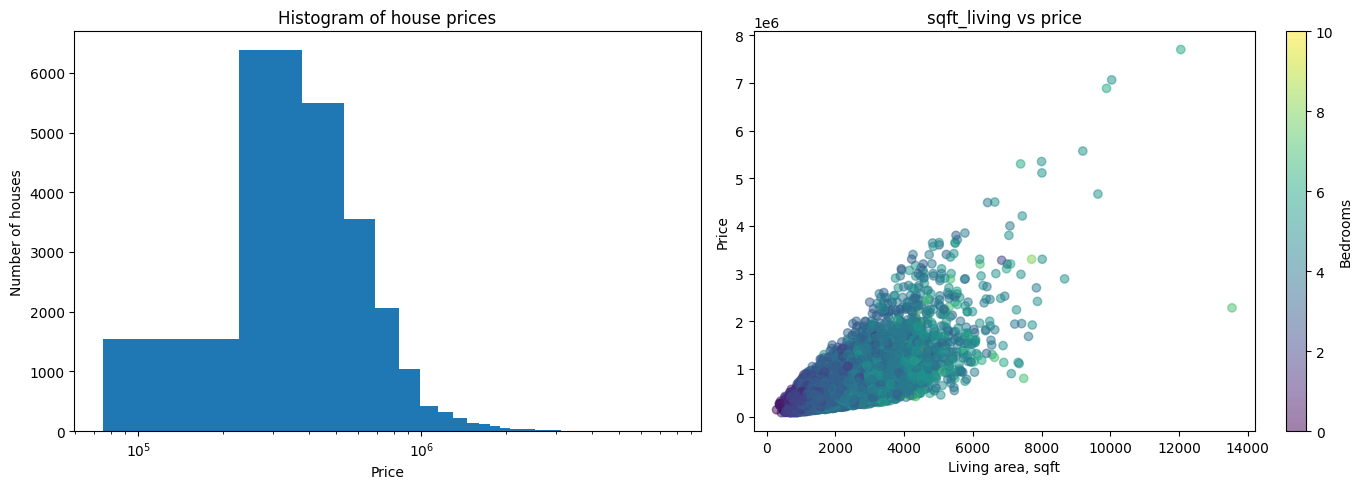

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sales["price"], bins=50)
axes[0].set_xscale("log")
axes[0].set_title("Histogram of house prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of houses")

scatter = axes[1].scatter(
    sales["sqft_living"],
    sales["price"],
    c=sales["bedrooms"],
    alpha=0.5,
    vmin=0,
    vmax=10
)

axes[1].set_title("sqft_living vs price")
axes[1].set_xlabel("Living area, sqft")
axes[1].set_ylabel("Price")

colorbar = fig.colorbar(scatter, ax=axes[1])
colorbar.set_label("Bedrooms")

plt.tight_layout()
plt.show()

**Спостереження (лівий графік):** Гістограма показує правосторонню асиметрію з крутим підйомом зліва та плавним логарифмічним спадом праворуч, тобто більшість будинків зосереджена в нижчому ціновому діапазоні, а дорожчі за 10^6 варіанти трапляються рідше.

**Спостереження (правий графік):** Між житловою площею та ціною спостерігається позитивна залежність: зі збільшенням площі будинку ціна загалом також зростає. Водночас точки мають помітний розкид, тобто на ціну впливають не лише площа та кількість спалень, а й інші фактори. Колір точок показує bedrooms: більша кількість спалень частіше зустрічається у будинків з більшою площею, але сама по собі не повністю пояснює ціну.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [11]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)

X_train = train_data[["sqft_living"]]
y_train = train_data["price"]

X_test = test_data[["sqft_living"]]
y_test = test_data["price"]

In [12]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
model = LinearRegression()

model.fit(X_train, y_train)
model.score(X_test, y_test)

intercept = model.intercept_

coefficient = model.coef_[0]

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

predicted_price = model.predict(pd.DataFrame({"sqft_living": [2500]}))

In [13]:
print("Вільний член (intercept):", intercept)
print("Коефіцієнт для sqft_living:", coefficient)
print("MSE на тестовій вибірці:", mse)
print("RMSE на тестовій вибірці:", rmse)
print("Передбачувана ціна будинку площею 2500 кв. футів:", predicted_price)

Вільний член (intercept): -41999.18603993731
Коефіцієнт для sqft_living: 279.55477931526383
MSE на тестовій вибірці: 76484977061.77612
RMSE на тестовій вибірці: 276559.1746114674
Передбачувана ціна будинку площею 2500 кв. футів: [656887.76224822]


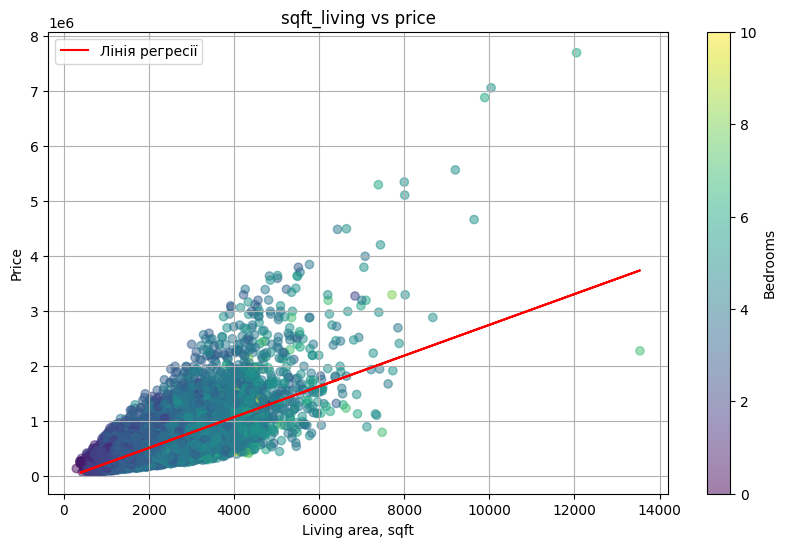

In [14]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    sales["sqft_living"],
    sales["price"],
    c=sales["bedrooms"].clip(upper=10),
    alpha=0.5,
    vmin=0,
    vmax=10
)

colorbar = plt.colorbar(scatter)
colorbar.set_label("Bedrooms")

x_line = np.linspace(
    sales["sqft_living"].min(),
    sales["sqft_living"].max(),
    100
)

x_line_df = pd.DataFrame({"sqft_living": x_line})
y_line = model.predict(x_line_df)

plt.plot(X_test["sqft_living"], y_pred, color="red", label="Лінія регресії")

plt.title("sqft_living vs price")
plt.xlabel("Living area, sqft")
plt.ylabel("Price")

plt.legend()
plt.grid(True)
plt.show()

---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [15]:
# Завдання 5 — Порівняння двох моделей

# Ознаки для двох моделей
features_model_1 = ["sqft_living"]
features_model_2 = ["sqft_living", "bedrooms", "bathrooms", "yr_built"]

# Дані для Моделі 1
X_train_1 = train_data[features_model_1]
X_test_1 = test_data[features_model_1]

# Дані для Моделі 2
X_train_2 = train_data[features_model_2]
X_test_2 = test_data[features_model_2]

# Цільова змінна
y_train = train_data["price"]
y_test = test_data["price"]

# Модель 1: тільки sqft_living
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train)

y_pred_1 = model_1.predict(X_test_1)

mse_1 = mean_squared_error(y_test, y_pred_1)
rmse_1 = np.sqrt(mse_1)

# Модель 2: sqft_living, bedrooms, bathrooms, yr_built
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)

y_pred_2 = model_2.predict(X_test_2)

mse_2 = mean_squared_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mse_2)

# Порівняння результатів
comparison = pd.DataFrame({
    "Модель": [
        "Модель 1: sqft_living",
        "Модель 2: sqft_living + bedrooms + bathrooms + yr_built"
    ],
    "MSE": [mse_1, mse_2],
    "RMSE": [rmse_1, rmse_2]
})

display(comparison)

# Висновок
if rmse_1 < rmse_2:
    print("Нижче значення RMSE має Модель 1.")
elif rmse_2 < rmse_1:
    print("Нижче значення RMSE має Модель 2.")
else:
    print("Обидві моделі мають однакове значення RMSE.")

,Модель,MSE,RMSE
0,Модель 1: sqft_living,7.648498e+10,276559.174611
1,Модель 2: sqft_living + bedrooms + bathrooms +...,6.916162e+10,262985.975872


Нижче значення RMSE має Модель 2.


**Відповідь:** Модель 2 має нижче значення RMSE, тому вона є точнішою на тестовій вибірці. Додавання додаткових характеристик будинку дозволяє моделі краще пояснити зміну ціни, ніж використання лише площі.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

Краща модель: Модель 2
RMSE кращої моделі: 262985.98
Середній залишок: -1611.51
Стандартне відхилення залишків: 262981.04


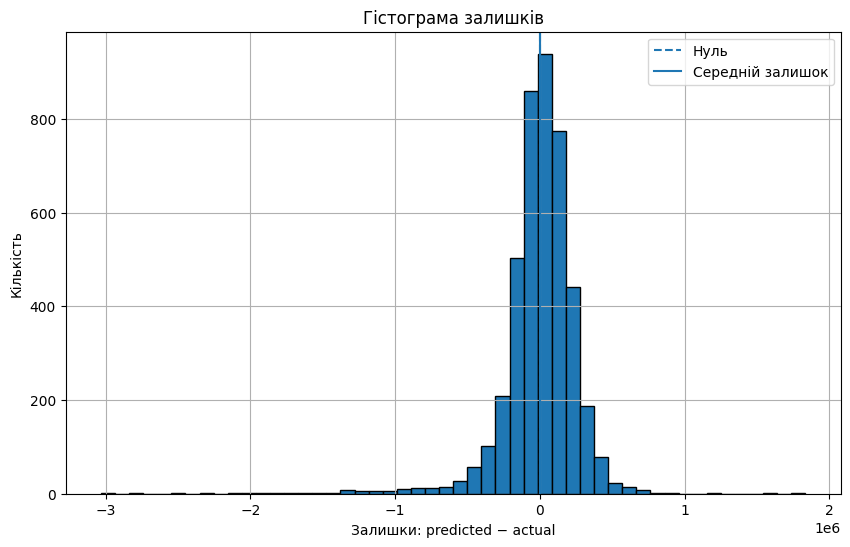

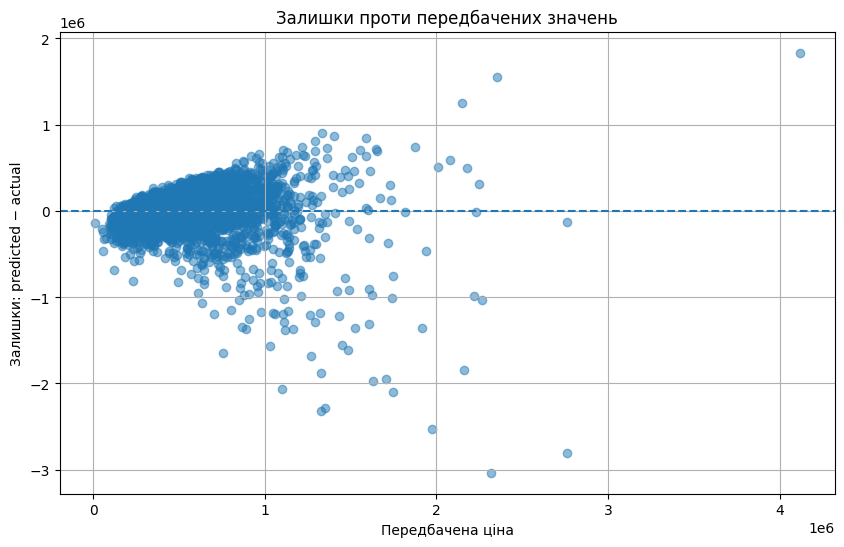

In [16]:
# Бонус — аналіз залишків
# Бонус — Аналіз залишків

# Вибираємо кращу модель за нижчим RMSE
if rmse_1 < rmse_2:
    best_model_name = "Модель 1"
    best_predictions = y_pred_1
    best_rmse = rmse_1
else:
    best_model_name = "Модель 2"
    best_predictions = y_pred_2
    best_rmse = rmse_2

# Залишки: predicted - actual
residuals = best_predictions - y_test

# Основні статистики залишків
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

print(f"Краща модель: {best_model_name}")
print(f"RMSE кращої моделі: {best_rmse:.2f}")
print(f"Середній залишок: {mean_residual:.2f}")
print(f"Стандартне відхилення залишків: {std_residual:.2f}")

# Гістограма залишків

plt.figure(figsize=(10, 6))

plt.hist(residuals, bins=50, edgecolor="black")

plt.axvline(0, linestyle="--", label="Нуль")
plt.axvline(mean_residual, linestyle="-", label="Середній залишок")

plt.title("Гістограма залишків")
plt.xlabel("Залишки: predicted − actual")
plt.ylabel("Кількість")

plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))

plt.scatter(best_predictions, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.title("Залишки проти передбачених значень")
plt.xlabel("Передбачена ціна")
plt.ylabel("Залишки: predicted − actual")

plt.grid(True)
plt.show()

Залишки були обчислені як різниця між очікуваним значенням та отриманим. Для кращої моделі середній залишок становить приблизно -1611.51, тобто він дуже близький до нуля порівняно з масштабом цін. Це означає, що модель у середньому не має сильного систематичного зміщення.

Гістограма залишків має найбільшу концентрацію значень біля нуля, однак розподіл не є ідеально нормальним. Видно довгі хвости та окремі великі відхилення, що пов'язано з наявністю дорогих будинків і викидів у даних.

Оскільки середній залишок від'ємний, модель у середньому незначно занижує ціну, тобто передбачені значення трохи менші за реальні. Але це зміщення є малим порівняно з RMSE, тому його не можна вважати суттєвим.

На графіку залишків проти передбачених значень також видно, що для дорожчих будинків розкид помилок збільшується. Це означає, що модель гірше працює для об'єктів з високою ціною, ймовірно через те, що проста лінійна регресія не повністю описує складну залежність ціни від характеристик будинку.